# Plot Gene-Peak links on trajectory

In [1]:
import mudata
scplus_mdata = mudata.read("outs/scplusmdata.h5mu")
scplus_mdata

/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed i

MuData object with n_obs × n_vars = 11745 × 206822
  uns:	'direct_e_regulon_metadata', 'extended_e_regulon_metadata'
  6 modalities
    scRNA_counts:	11745 x 36601
      obs:	'sample2', 'barcode2', 'celltype'
      var:	'gene_ids', 'feature_types'
    scATAC_counts:	11745 x 169879
      obs:	'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'sample2', 'barcode2', 'celltype'
      var:	'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
    direct_gene_based_AUC:	11745 x 98
    direct_region_based_AUC:	11745 x 98
    extended_gene_based_AUC:	11745 x 73
    extended_region_based_AUC:	11745 x 73

In [2]:
adata_rna = scplus_mdata.mod['scRNA_counts']
adata_rna.obs['group'] = adata_rna.obs['sample2'].astype(str) + '_' + adata_rna.obs['barcode2'].astype(str)
adata_rna.obs.index = adata_rna.obs.index.str.split('___').str[0]
adata_rna

AnnData object with n_obs × n_vars = 11745 × 36601
    obs: 'sample2', 'barcode2', 'celltype', 'group'
    var: 'gene_ids', 'feature_types'

In [3]:
adata_atac = scplus_mdata.mod['scATAC_counts']
adata_atac.obs['group'] = adata_atac.obs['sample2'].astype(str) + '_' + adata_atac.obs['barcode2'].astype(str)
adata_atac.obs.index = adata_atac.obs.index.str.split('___').str[0]
adata_atac

AnnData object with n_obs × n_vars = 11745 × 169879
    obs: 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'sample2', 'barcode2', 'celltype', 'group'
    var: 'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'

In [4]:
import pandas as pd
anno = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scanpy/IPC/ipc_four_lineage.csv", index_col=0)
# anno['progress'] = anno['is_Oligo_lineage'].map({1: 'gliogenesis', 0: 'neurogenesis'})
# index_progress_dict = anno['progress'].to_dict()
# adata_rna.obs['progress'] = adata_rna.obs.index.map(index_progress_dict)
# adata_atac.obs['progress'] = adata_atac.obs.index.map(index_progress_dict)
anno['is_Neuro_lineage'] = anno[['is_ExN_lineage', 'is_InN_lineage']].max(axis=1)
adata_rna.obs[['is_Neuro_lineage', 'is_Oligo_lineage', 'is_Astro_lineage']] = anno[['is_Neuro_lineage', 'is_Oligo_lineage', 'is_Astro_lineage']]
adata_atac.obs[['is_Neuro_lineage', 'is_Oligo_lineage', 'is_Astro_lineage']] = anno[['is_Neuro_lineage', 'is_Oligo_lineage', 'is_Astro_lineage']]

In [5]:
import pandas as pd
import numpy as np
import ast

region_to_gene = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/IPC/outs/region_to_gene_adj.tsv",sep = '\t')
region_df = region_to_gene.copy()

In [7]:
# Rows where is_Neuro_lineage==1 or is_Oligo_lineage==1
adata_subset_rna = adata_rna[(adata_rna.obs['is_Neuro_lineage'] == 1) | (adata_rna.obs['is_Oligo_lineage'] == 1)].copy()
adata_subset_atac = adata_atac[(adata_atac.obs['is_Neuro_lineage'] == 1) | (adata_atac.obs['is_Oligo_lineage'] == 1)].copy()

In [19]:
import pandas as pd
import numpy as np
from scipy import stats
from joblib import Parallel, delayed
import multiprocessing
import scipy.sparse

# Prepare global matrices
X_rna_all = adata_subset_rna.X
X_atac_all = adata_subset_atac.X

# CSC for faster column slicing if sparse
if scipy.sparse.issparse(X_rna_all):
    X_rna_all = X_rna_all.tocsc()
if scipy.sparse.issparse(X_atac_all):
    X_atac_all = X_atac_all.tocsc()

# Index maps
gene_mapping = {name: i for i, name in enumerate(adata_rna.var_names)}
region_mapping = {name: i for i, name in enumerate(adata_atac.var_names)}

# ==========================================
# 2. Correlation worker
# ==========================================
def calculate_global_corr(sub_df, gene_map, region_map, x_rna, x_atac):
    results = []
    
    for _, row in sub_df.iterrows():
        gene = row['target']
        region = row['region']
        
        if gene not in gene_map or region not in region_map:
            continue
            
        # Extract vectors
        g_idx = gene_map[gene]
        r_idx = region_map[region]
        
        # Sparse or dense
        g_expr = x_rna[:, g_idx]
        if scipy.sparse.issparse(g_expr): g_expr = g_expr.toarray().flatten()
        else: g_expr = np.ravel(g_expr)
            
        r_acc = x_atac[:, r_idx]
        if scipy.sparse.issparse(r_acc): r_acc = r_acc.toarray().flatten()
        else: r_acc = np.ravel(r_acc)
        
        # Global Spearman rho
        if np.std(g_expr) == 0 or np.std(r_acc) == 0:
            rho, pval = 0.0, 1.0
        else:
            rho, pval = stats.spearmanr(r_acc, g_expr)
            
        results.append({
            'target': gene,
            'region': region,
            'global_rho': rho,
            'global_pval': pval
        })
    return results

# ==========================================
# 3. Parallel map
# ==========================================
n_jobs = 8
chunks = np.array_split(region_df, n_jobs * 4)

results_list = Parallel(n_jobs=n_jobs, verbose=5)(
    delayed(calculate_global_corr)(
        chunk, gene_mapping, region_mapping, X_rna_all, X_atac_all
    ) for chunk in chunks
)

# Concatenate results
global_stats = pd.DataFrame([item for sublist in results_list for item in sublist])

# ==========================================
# 4. Strict filtering
# ==========================================
# Thresholds:
GLOBAL_RHO_THRESHOLD = 0.03
GLOBAL_PVAL_THRESHOLD = 0.05

# Merge back to link table
df_clean = pd.merge(region_df, global_stats, on=['target', 'region'], how='inner')

# Keep significantly positive correlations
links_validated = df_clean[
    (df_clean['global_rho'].abs() > GLOBAL_RHO_THRESHOLD) & 
    (df_clean['global_pval'] < GLOBAL_PVAL_THRESHOLD)
].copy()

print(f"Raw links count: {len(region_df)}")
print(f"Valid links count: {len(links_validated)} (Filtered out {len(region_df) - len(links_validated)}  links)")

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:   28.6s
[Parallel(n_jobs=8)]: Done  24 out of  32 | elapsed:  1.4min remaining:   27.9s
[Parallel(n_jobs=8)]: Done  32 out of  32 | elapsed:  1.9min finished


Raw links count: 476976
Valid links count: 167889 (Filtered out 309087 links)


In [20]:
gene = 'NEK7'
subset = links_validated[links_validated['target'] == gene].copy()
subset

,target,region,importance,rho,importance_x_rho,importance_x_abs_rho,Distance,global_rho,global_pval
262659,NEK7,chr1:198391517-198392018,0.063413,-0.041287,-0.002618,0.002618,[-69348],-0.031982,2.241118e-03
262660,NEK7,chr1:198332459-198332960,0.061243,-0.065953,-0.004039,0.004039,[-10290],-0.063292,1.422942e-09
262661,NEK7,chr1:198158892-198159393,0.074648,-0.057044,-0.004258,0.004258,[0],-0.061514,4.040752e-09
262662,NEK7,chr1:198157400-198157901,0.069322,0.057900,0.004014,0.004014,[0],0.065009,5.055252e-10
262664,NEK7,chr1:198298631-198299132,0.035274,-0.066033,-0.002329,0.002329,[0],-0.066203,2.421751e-10
262667,NEK7,chr1:198246376-198246877,0.057424,-0.071128,-0.004084,0.004084,[0],-0.071896,6.083839e-12
262668,NEK7,chr1:198275493-198275994,0.015277,0.031374,0.000479,0.000479,[0],0.050259,1.550264e-06
262669,NEK7,chr1:198273785-198274286,0.046407,0.026400,0.001225,0.001225,[0],0.038526,2.313943e-04
262671,NEK7,chr1:198265179-198265680,0.115591,0.057895,0.006692,0.006692,[0],0.039983,1.326680e-04
262674,NEK7,chr1:198204898-198205399,0.084759,0.087210,0.007392,0.007392,[0],0.099257,1.975041e-21


# group

In [ ]:
import numpy as np
import pandas as pd
from scipy import sparse

# Group indices
idx_glio = np.where(adata_rna.obs['is_Oligo_lineage'] == 1)[0]
idx_neuro = np.where(adata_rna.obs['is_Neuro_lineage'] == 1)[0]

# Unique regions in links_validated
unique_regions = links_validated['region'].unique()
region_map = {name: i for i, name in enumerate(adata_atac.var_names)}

# Column indices for those regions
region_indices = [region_map[r] for r in unique_regions if r in region_map]
valid_regions = [r for r in unique_regions if r in region_map]

# Fast mean abundance (sparse-friendly)
# Submatrix for those regions
X_atac_sub = adata_atac.X[:, region_indices]

# Means per group
# Note: sparse.mean may return np.matrix -> ravel to array
mean_glio = np.array(X_atac_sub[idx_glio, :].mean(axis=0)).flatten()
mean_neuro = np.array(X_atac_sub[idx_neuro, :].mean(axis=0)).flatten()

Pseudocount to avoid div-by-zero
epsilon = 1e-6 
log2fc = np.log2((mean_glio + epsilon) / (mean_neuro + epsilon))

# Abundance summary table
df_abundance = pd.DataFrame({
    'region': valid_regions,
    'mean_atac_glio': mean_glio,
    'mean_atac_neuro': mean_neuro,
    'log2fc': log2fc
})

# Preference class labels
LOGFC_THRESHOLD =1 

def classify_abundance(fc):
    if fc > LOGFC_THRESHOLD:
        return 'Gliogenesis Enriched'
    elif fc < -LOGFC_THRESHOLD:
        return 'Neurogenesis Enriched'
    else:
        return 'Conserved'

df_abundance['abundance_class'] = df_abundance['log2fc'].apply(classify_abundance)

# Merge back into links table
# Drop old class column if present to avoid clashes
if 'abundance_class' in links_validated.columns:
    links_validated = links_validated.drop(columns=['abundance_class', 'mean_atac_glio', 'mean_atac_neuro', 'log2fc'])

# Merge
links_validated = pd.merge(links_validated, df_abundance, on='region', how='left')

In [22]:
links_validated

,target,region,importance,rho,importance_x_rho,importance_x_abs_rho,Distance,global_rho,global_pval,mean_atac_glio,mean_atac_neuro,log2fc,abundance_class
0,A2M,chr12:8949482-8949983,0.253489,-0.024216,-0.006138,0.006138,[-117932],-0.035838,6.147897e-04,40.526814,42.610286,-0.072325,Conserved
1,A2M,chr12:9049518-9050019,0.132616,-0.050615,-0.006712,0.006712,[-17896],-0.049830,1.901169e-06,0.120084,0.914286,-2.928589,Neurogenesis Enriched
2,A2ML1,chr12:8844630-8845131,0.108673,0.145178,0.015777,0.015777,[0],0.066350,2.210727e-10,1.240379,0.399543,1.634356,Gliogenesis Enriched
3,A2ML1,chr12:8687707-8688208,0.063232,0.125106,0.007911,0.007911,[134663],0.065557,3.611416e-10,14.777077,10.069486,0.553371,Conserved
4,A2ML1,chr12:8828666-8829167,0.073730,0.167769,0.012370,0.012370,[0],0.103009,5.756088e-23,0.503470,0.016000,4.975675,Gliogenesis Enriched
...,...,...,...,...,...,...,...,...,...,...,...,...,...
167884,ZZEF1,chr17:4229528-4230029,0.024294,0.052167,0.001267,0.001267,[86748],0.032721,1.766376e-03,0.221241,0.000914,7.917186,Gliogenesis Enriched
167885,ZZEF1,chr17:4220606-4221107,0.034917,0.069528,0.002428,0.002428,[77826],0.054074,2.341678e-07,0.201893,0.176914,0.190538,Conserved
167886,ZZEF1,chr17:4215282-4215783,0.022595,0.030239,0.000683,0.000683,[72502],0.031306,2.774481e-03,3.832387,3.851429,-0.007150,Conserved
167887,ZZEF1,chr17:4221849-4222350,0.019451,0.047175,0.000918,0.000918,[79070],0.047649,5.242089e-06,0.615142,0.856686,-0.477846,Conserved


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

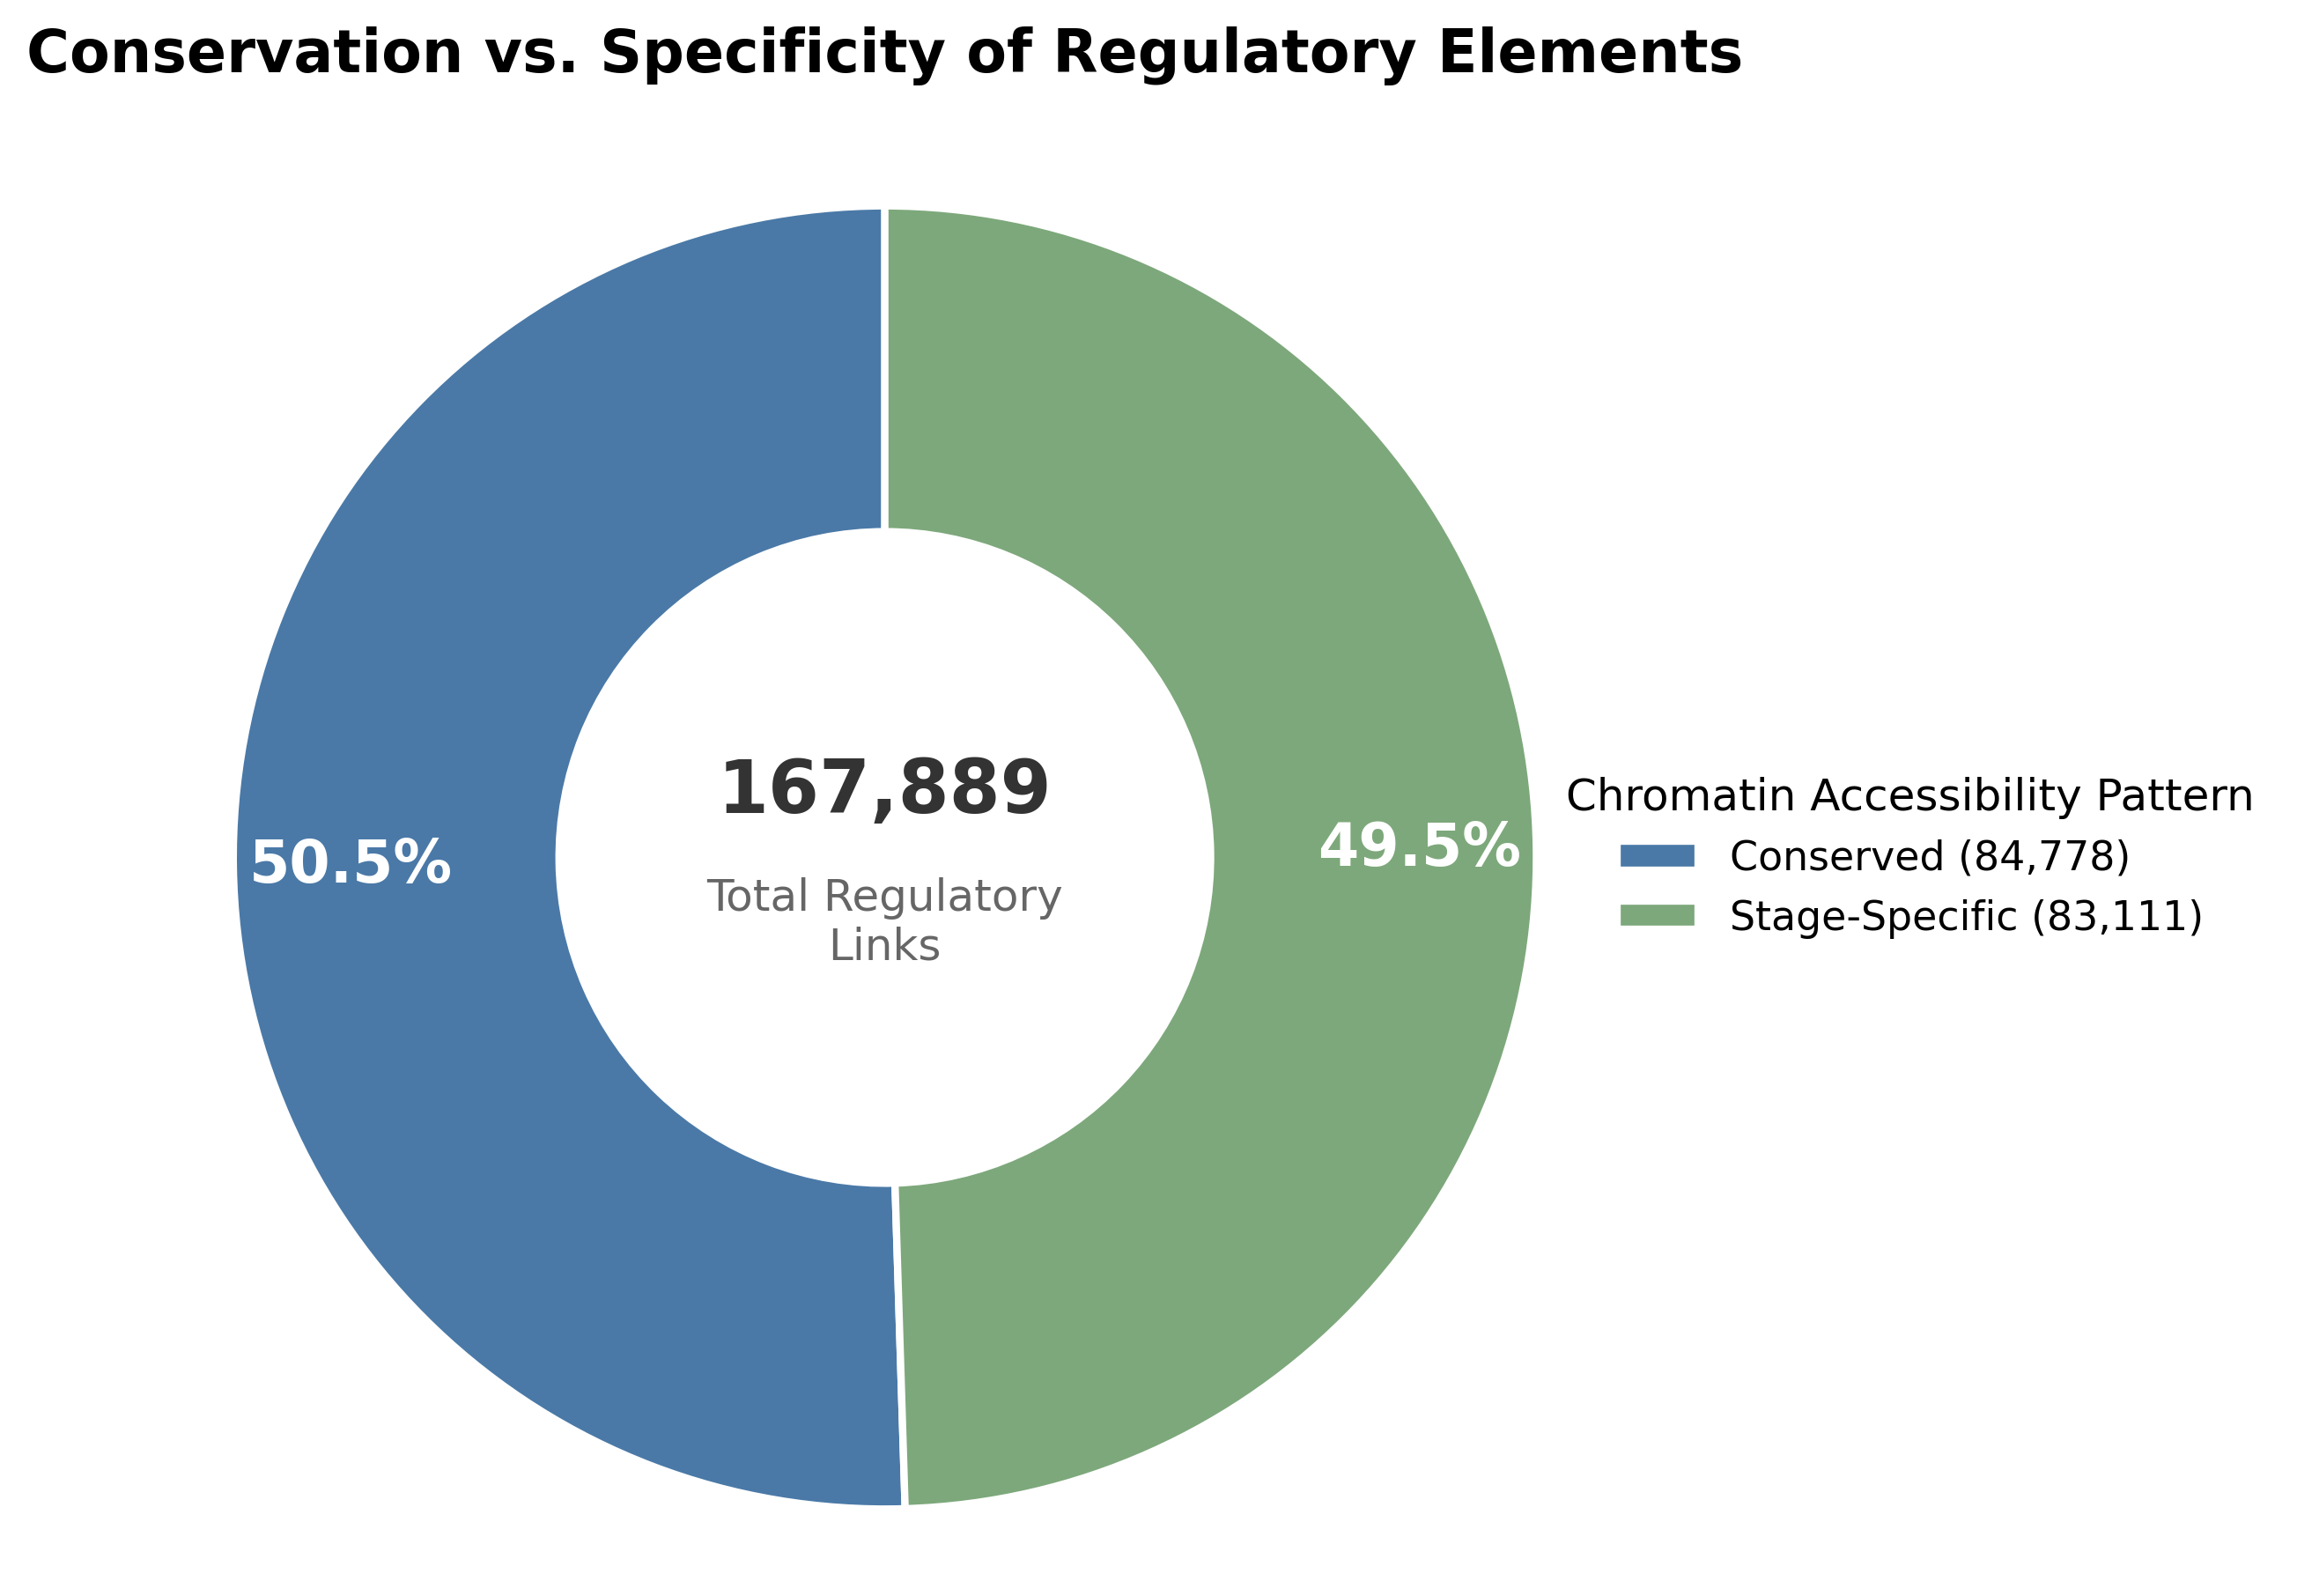

In [10]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

# Illustrator-friendly PDF
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial']

# Summary stats
# Count per category
counts = links_validated['abundance_class'].value_counts()

# Extract values
n_conserved = counts.get('Conserved', 0)
# Merge Neuro- and Glio-specific labels into "Specific"
n_neuro_spec = counts.get('Neurogenesis Enriched', 0)
n_glio_spec = counts.get('Gliogenesis Enriched', 0)
n_specific = n_neuro_spec + n_glio_spec

# Data for plotting
sub_labels = ['Conserved Accessibility', 'Stage-Specific Accessibility']
sub_sizes = [n_conserved, n_specific]
sub_total = sum(sub_sizes)

# Percentages for logging
pct_conserved = (n_conserved / sub_total) * 100
pct_specific = (n_specific / sub_total) * 100

# Plot kwargs
sub_colors = ['#4A79A7', '#7DA87B']

# Donut chart
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

wedges, texts, autotexts = ax.pie(
    sub_sizes, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=sub_colors, 
    pctdistance=0.82, # pct distance from center
    wedgeprops={'width': 0.5, 'edgecolor': 'white', 'linewidth': 2}, # wedge width
    textprops={'fontsize': 16, 'fontweight': 'bold', 'color': 'white'}
)

# Total in center
ax.text(0, 0.1, f'{sub_total:,}', 
        ha='center', va='center', 
        fontsize=20, fontweight='bold', color='#333333')

# Subtitle below center
ax.text(0, -0.1, 'Total Regulatory\nLinks', 
        ha='center', va='center', 
        fontsize=12, color='#666666')

# Legend
legend_labels = [
    f'Conserved ({n_conserved:,})', 
    f'Stage-Specific ({n_specific:,})'
]

ax.legend(
    wedges, legend_labels,
    title="Chromatin Accessibility Pattern",
    title_fontsize=12,
    loc="center left",
    bbox_to_anchor=(0.95, 0, 0.5, 1), # Legend on the right
    fontsize=11,
    frameon=False
)

# Title and save
ax.set_title('Conservation vs. Specificity of Regulatory Elements', 
             fontsize=16, fontweight='bold', pad=20)
ax.axis('equal')  # Equal aspect (circle)

# Output path (edit as needed)
plt.savefig("./plot/Regulatory_Conservation_Pie.pdf", format='pdf', bbox_inches='tight', transparent=True)
plt.show()

Done: total genes = 11311.
  gene_symbol  link_count
0        GSE1         204
1       AUTS2         186
2        KAZN         164
3      PTPRN2         164
4         NTM         158
5      RBFOX1         153
6       CSMD1         142
7        MSI2         138
8      PRDM16         137
9      SORCS2         129


/tmp/ipykernel_3642498/874505408.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 's

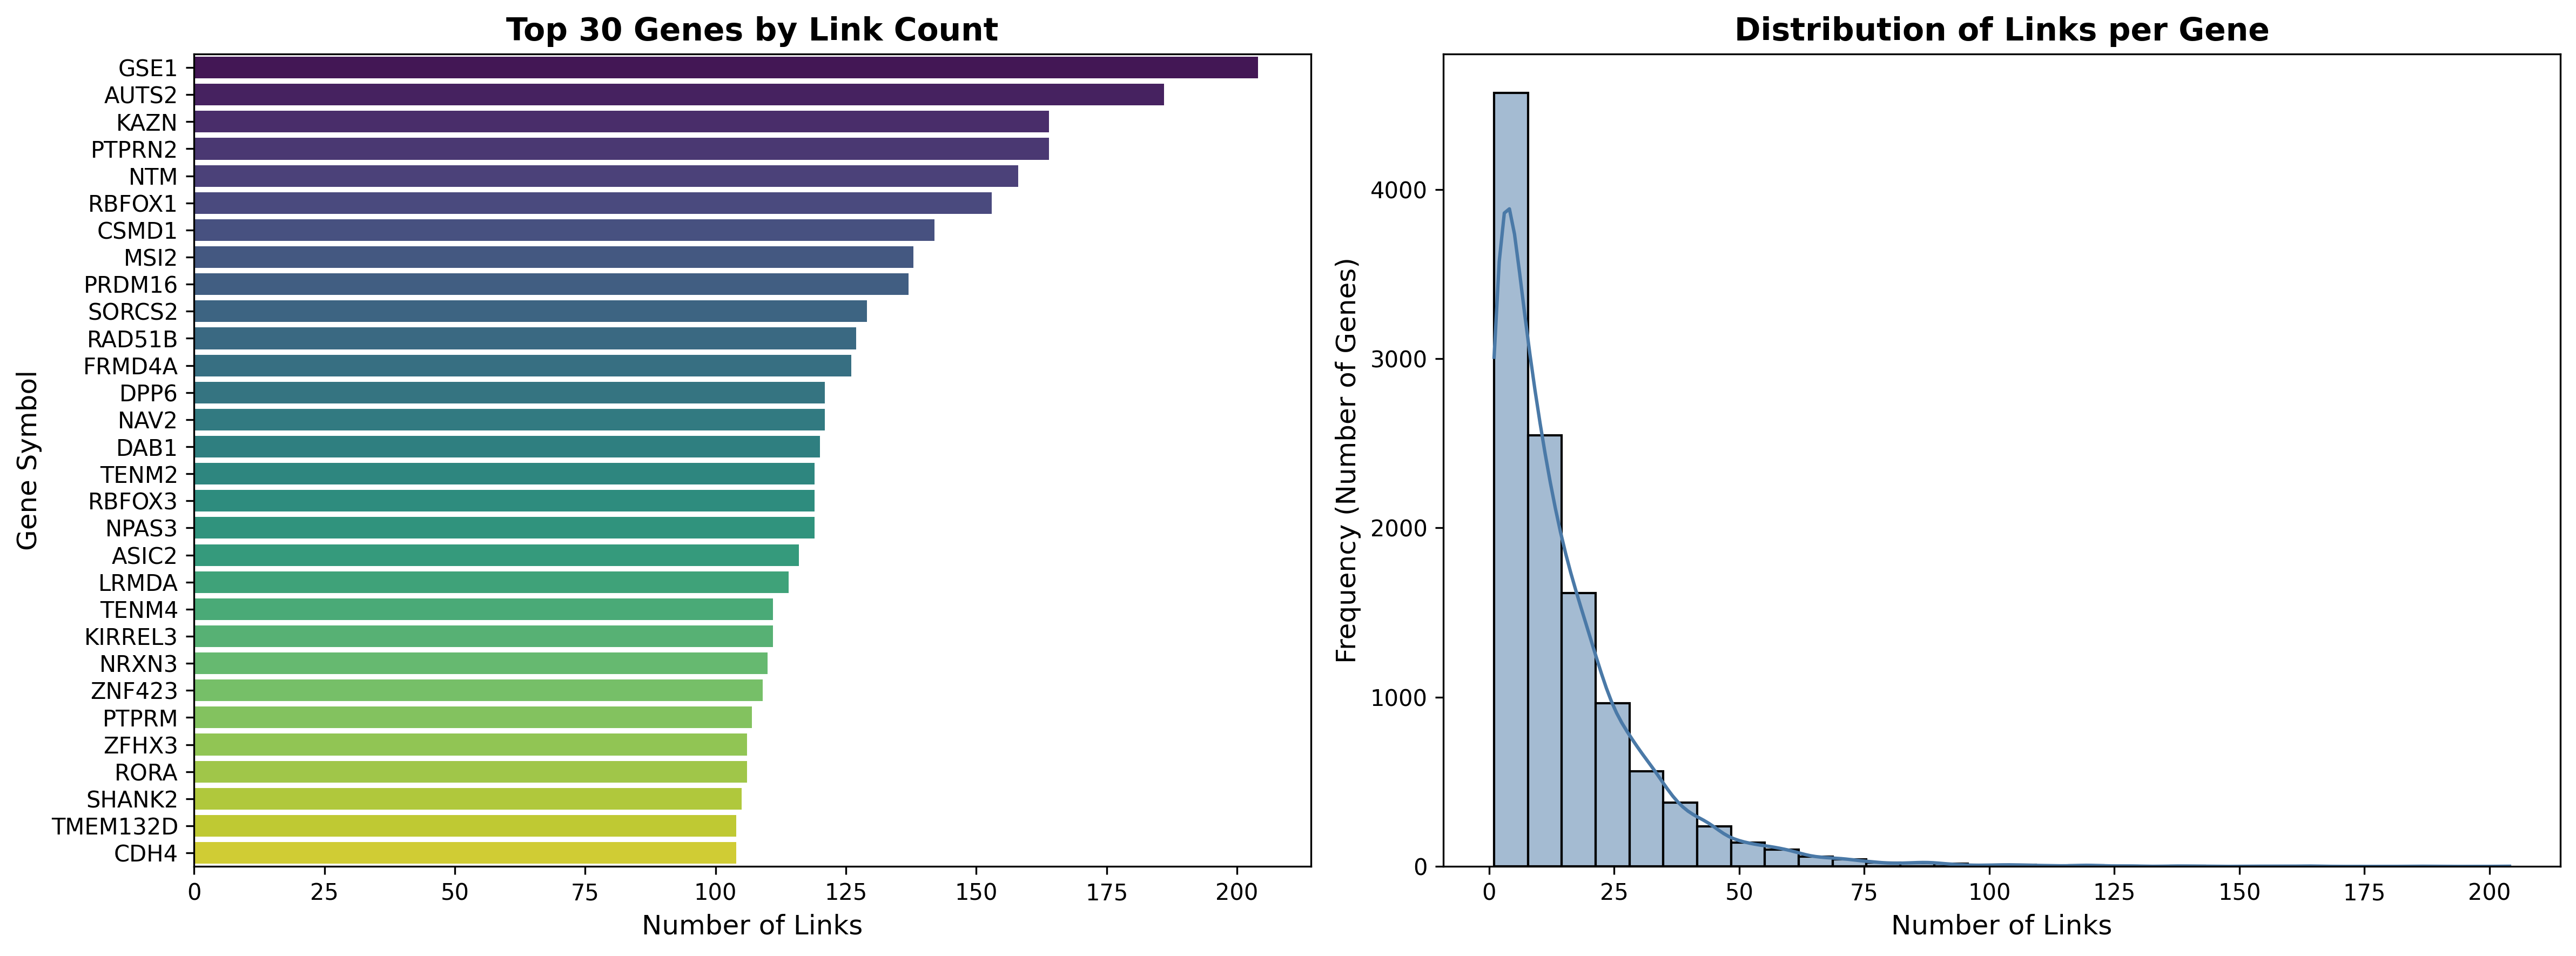

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 0. PDF export settings
# =========================
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# =========================
# 1. Count links per gene
# =========================
# Occurrences per target
gene_link_counts = links_validated['target'].value_counts().reset_index()
gene_link_counts.columns = ['gene_symbol', 'link_count']

print(f"Done: total genes = {len(gene_link_counts)}.")
print(gene_link_counts.head(10)) # Show top 10

# =========================
# 2. Bar plot: top 30 genes
# =========================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# Panel A: top 30 hub genes
top_n = 30
sns.barplot(
    data=gene_link_counts.head(top_n),
    x='link_count',
    y='gene_symbol',
    palette='viridis',
    ax=ax1
)
ax1.set_title(f'Top {top_n} Genes by Link Count', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Links', fontsize=12)
ax1.set_ylabel('Gene Symbol', fontsize=12)

# Panel B: histogram of link counts per gene
sns.histplot(
    gene_link_counts['link_count'],
    bins=30,
    kde=True,
    color='#4A79A7',
    ax=ax2
)
ax2.set_title('Distribution of Links per Gene', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Links', fontsize=12)
ax2.set_ylabel('Frequency (Number of Genes)', fontsize=12)

plt.tight_layout()

# Save figure
# plt.savefig("./plot/Gene_Link_Counts_Statistics.pdf", bbox_inches='tight')
plt.show()

/tmp/ipykernel_3642498/2054406187.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic fam

Category counts:
Dual Identity     4712
Conserved Gene     686
Specific Gene      483
Name: category, dtype: int64


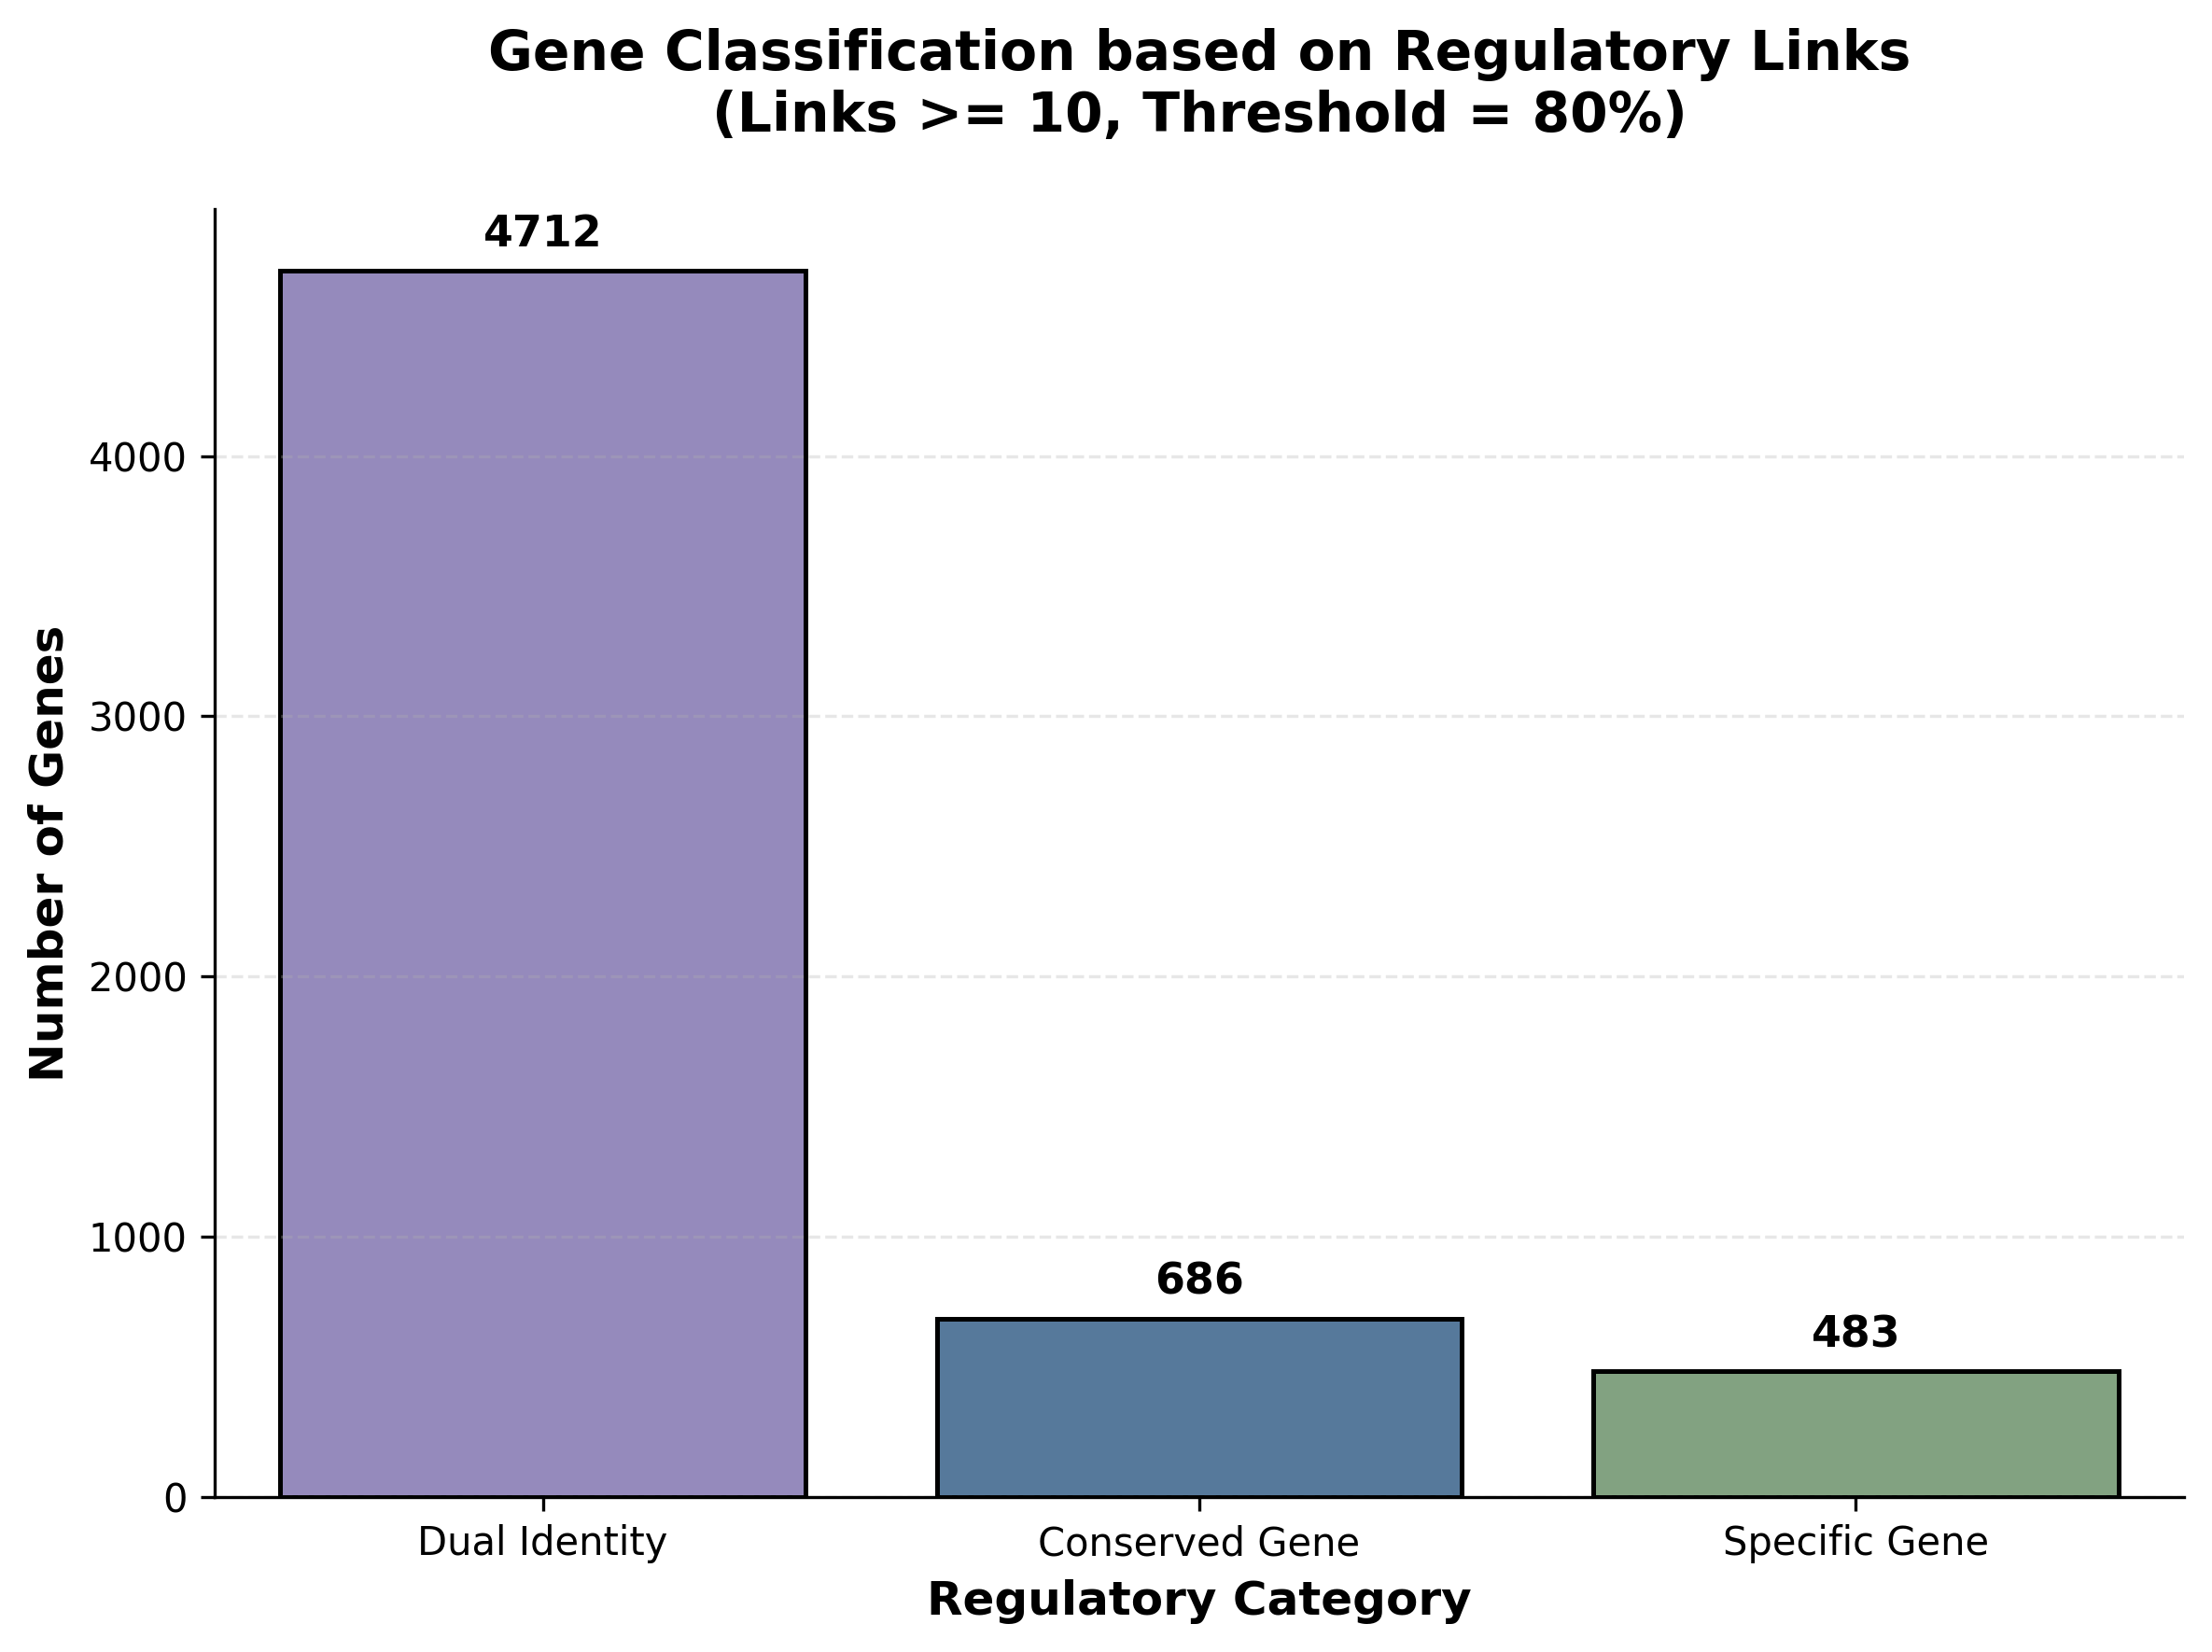

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================
# 0. PDF export settings
# =========================
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# =========================
# 1. Per-gene stats and filter
# =========================
df = links_validated.copy()

# Tag link type
df["is_conserved"] = df["abundance_class"] == "Conserved"
df["is_enriched"] = df["abundance_class"].str.contains("Enriched", na=False)

# Aggregate by gene
gene_stats = df.groupby("target").agg(
    total_links=('target', 'size'),
    cons_count=('is_conserved', 'sum'),
    spec_count=('is_enriched', 'sum')
).reset_index()

# Keep genes with >=10 links
filtered_genes = gene_stats[gene_stats['total_links'] >= 10].copy()

# =========================
# 2. Fractions and categories
# =========================
# Proportions
filtered_genes['pct_cons'] = filtered_genes['cons_count'] / filtered_genes['total_links']
filtered_genes['pct_spec'] = filtered_genes['spec_count'] / filtered_genes['total_links']

# Classification rule
def classify_gene(row):
    if row['pct_cons'] >= 0.75:
        return 'Conserved Gene'
    elif row['pct_spec'] >= 0.75:
        return 'Specific Gene'
    else:
        return 'Dual Identity'

filtered_genes['category'] = filtered_genes.apply(classify_gene, axis=1)

# Count categories
category_counts = filtered_genes['category'].value_counts().reindex(
    ['Dual Identity', 'Conserved Gene', 'Specific Gene']
).fillna(0)

print("Category counts:")
print(category_counts)

# =========================
# 3. Bar chart
# =========================
plt.figure(figsize=(8, 6), dpi=300)

# Colors: dual, conserved, specific
colors = ['#9182C4', '#4A79A7', '#7DA87B']

ax = sns.barplot(
    x=category_counts.index, 
    y=category_counts.values, 
    palette=colors,
    edgecolor='black',
    linewidth=1.2
)

# Value labels on bars
for i, v in enumerate(category_counts.values):
    ax.text(i, v + (max(category_counts.values) * 0.02), 
            str(int(v)), ha='center', fontweight='bold', fontsize=11)

# Polish axes
plt.title('Gene Classification based on Regulatory Links\n(Links >= 10, Threshold = 80%)', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Number of Genes', fontsize=12, fontweight='bold')
plt.xlabel('Regulatory Category', fontsize=12, fontweight='bold')

# Remove top/right spines
sns.despine()

# Optional y-grid
plt.grid(axis='y', linestyle='--', alpha=0.3)

# =========================
# 4. Save
# =========================
plt.tight_layout()
# plt.savefig("./plot/Gene_Category_Refined_Bar.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [30]:
filtered_genes

,target,total_links,cons_count,spec_count,pct_cons,pct_spec,category
2,AAAS,13,12,1,0.923077,0.076923,Conserved Gene
5,AAGAB,21,9,12,0.428571,0.571429,Dual Identity
13,AASS,17,10,7,0.588235,0.411765,Dual Identity
14,AATK,44,23,21,0.522727,0.477273,Dual Identity
15,ABAT,31,15,16,0.483871,0.516129,Dual Identity
...,...,...,...,...,...,...,...
11301,ZSWIM8,11,6,5,0.545455,0.454545,Dual Identity
11302,ZSWIM9,10,6,4,0.600000,0.400000,Dual Identity
11305,ZWILCH,20,10,10,0.500000,0.500000,Dual Identity
11307,ZXDC,31,17,14,0.548387,0.451613,Dual Identity


In [31]:
gene = 'NEK7'
subset = filtered_genes[filtered_genes['target'] == gene].copy()
subset

,target,total_links,cons_count,spec_count,pct_cons,pct_spec,category
6043,NEK7,11,3,8,0.272727,0.727273,Dual Identity


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

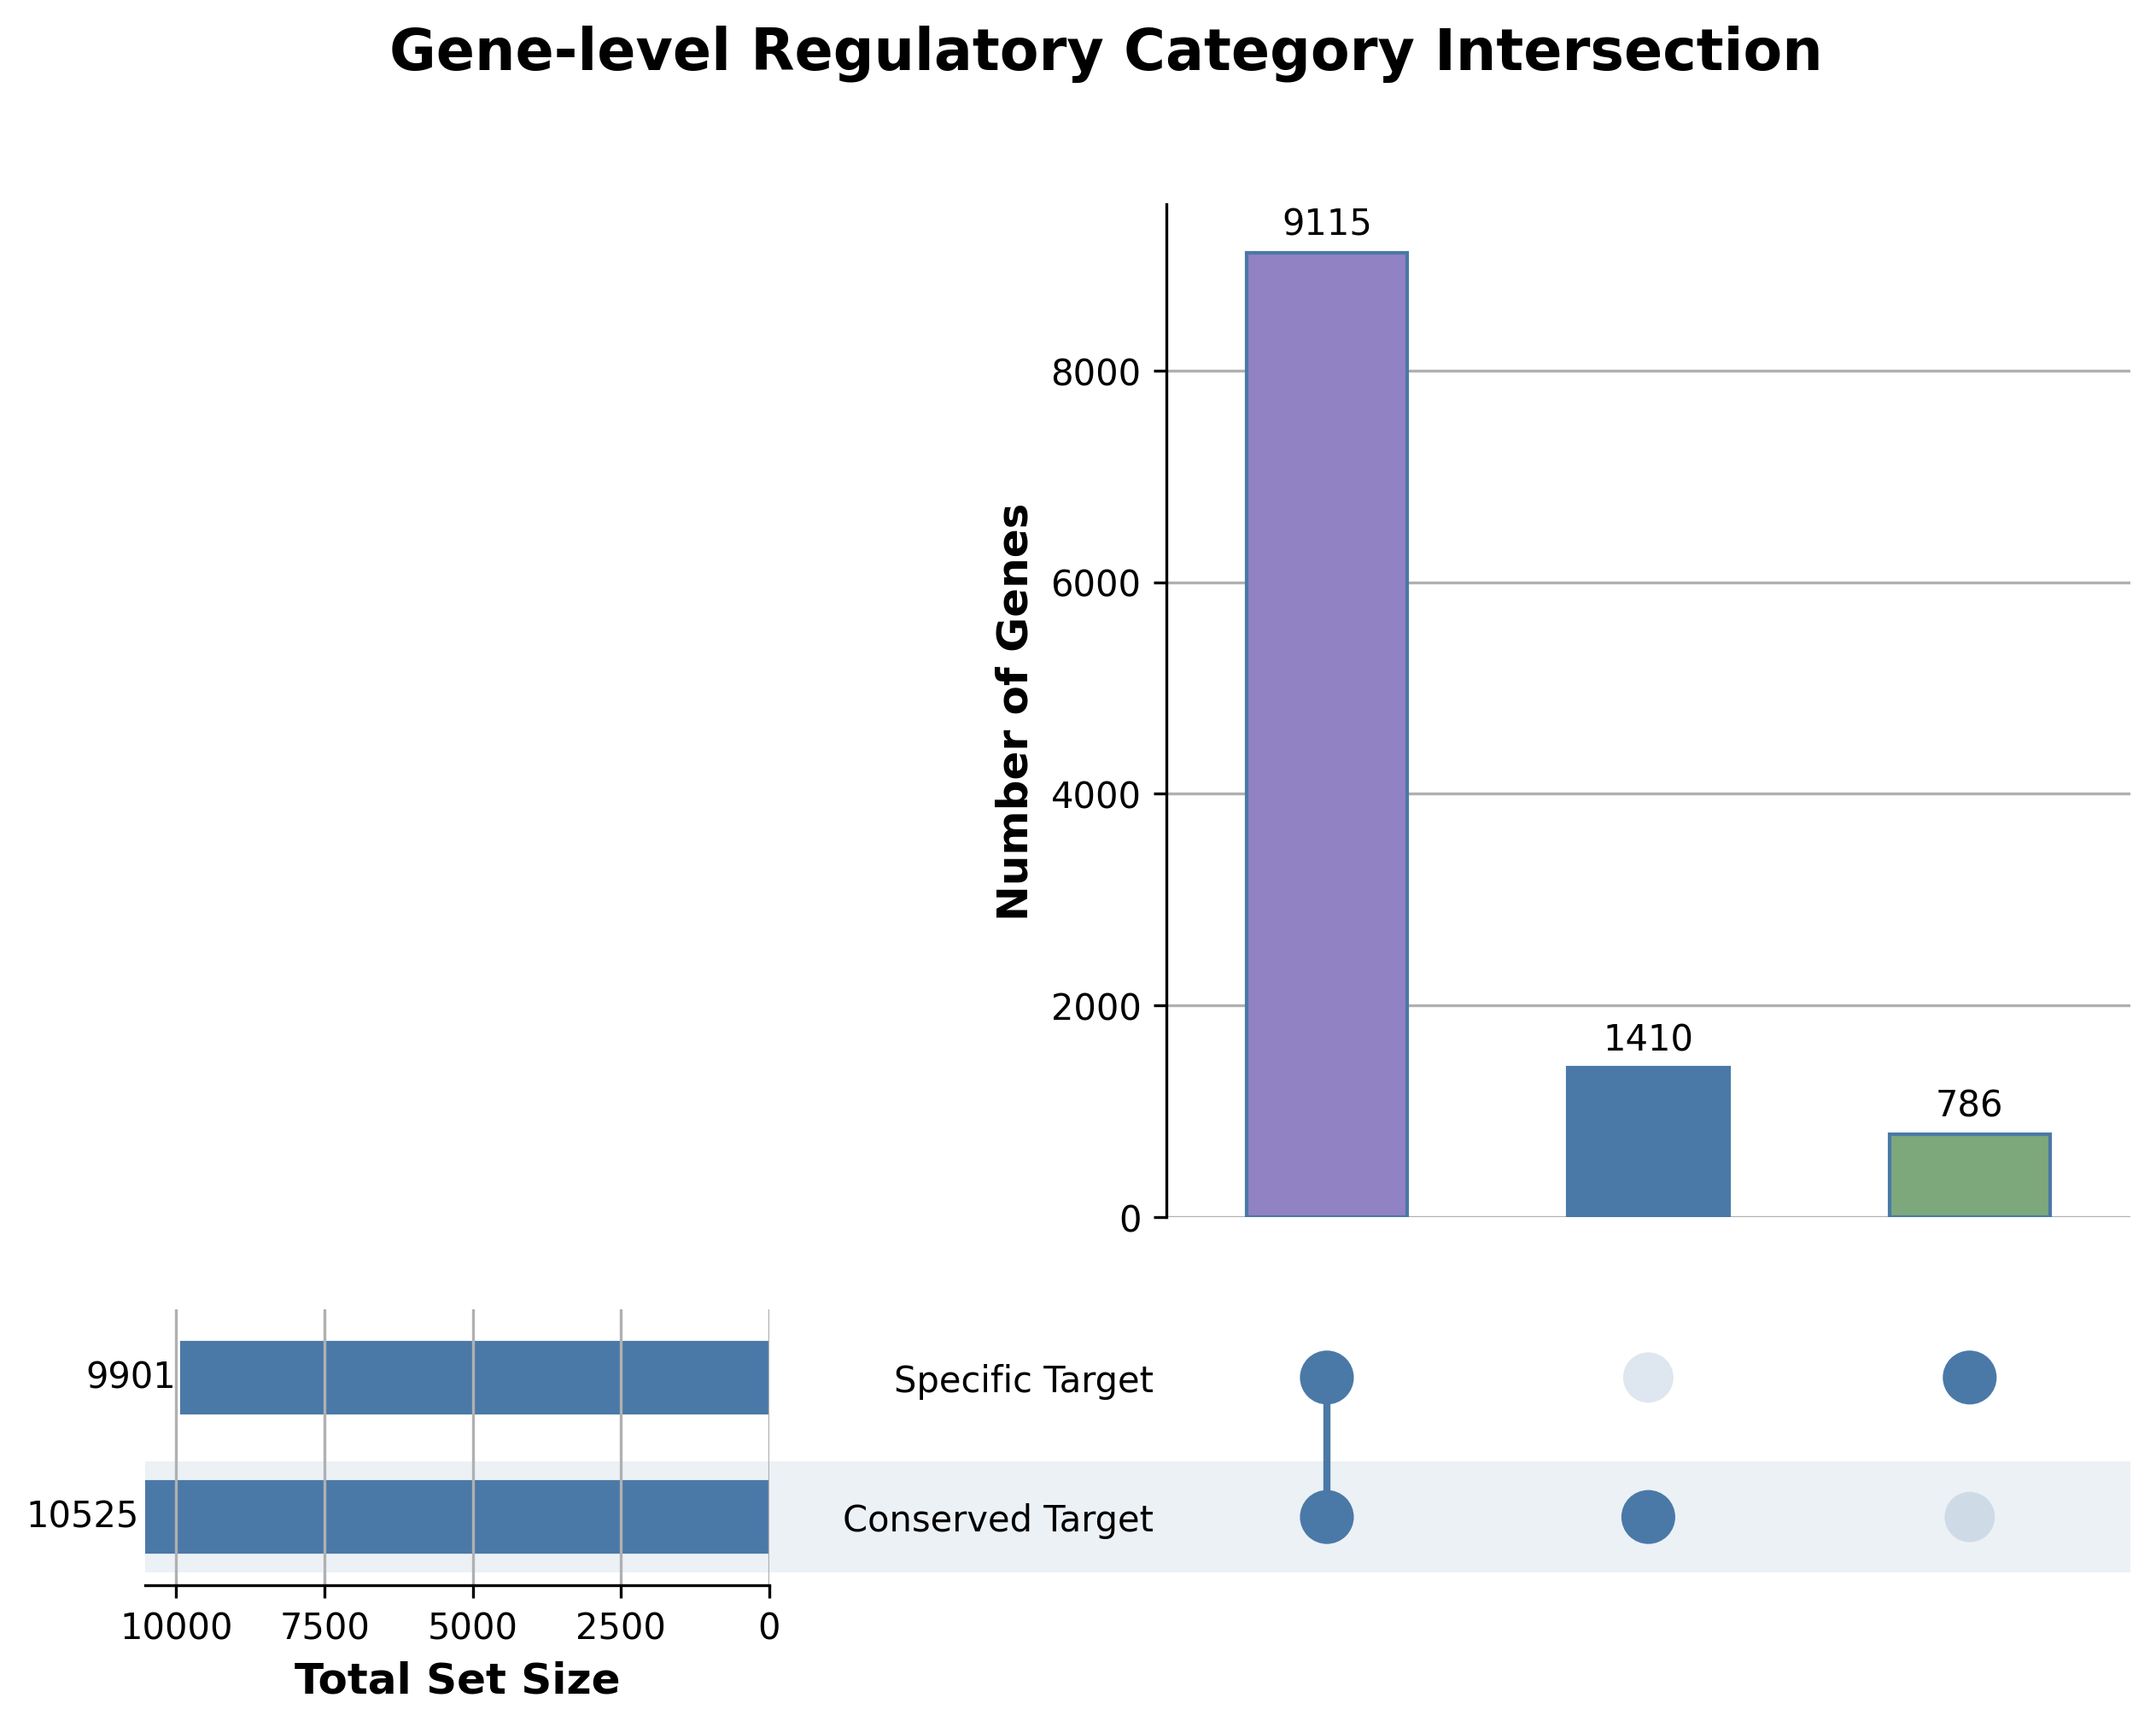

In [29]:
import pandas as pd
from upsetplot import from_contents, plot
import matplotlib.pyplot as plt
import matplotlib

# =========================
# 0. PDF (editable text)
# =========================
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial']

# =========================
# 1. Gene-level labels
# =========================
df = links_validated.copy()

df["is_conserved"] = df["abundance_class"] == "Conserved"
df["is_enriched"] = df["abundance_class"].str.contains("Enriched", na=False)

gene_level = (
    df.groupby("target")
      .agg({
          "is_conserved": "any",
          "is_enriched": "any"
      })
)

# Two sets for UpSet
genes_conserved = set(gene_level[gene_level["is_conserved"]].index)
genes_enriched = set(gene_level[gene_level["is_enriched"]].index)

contents = {
    'Conserved Target': list(genes_conserved),
    'Specific Target': list(genes_enriched)
}

data = from_contents(contents)

# =========================
# 2. Figure
# =========================
fig = plt.figure(figsize=(10, 7), dpi=300)

upset = plot(
    data,
    fig=fig,
    element_size=None,
    facecolor="#4A79A7",
    shading_color=0.1,
    show_counts=True,
    sort_by='cardinality',
    sort_categories_by=None
)

# =========================
# 3. Dynamic bar colors
# =========================
ax_inter = upset['intersections']
patches = ax_inter.patches

# Sort by height; largest intersection purple
bars_with_height = sorted(
    [(p, p.get_height()) for p in patches],
    key=lambda x: x[1],
    reverse=True
)

colors = ['#9182C4', '#4A79A7', '#7DA87B']

for i, (patch, _) in enumerate(bars_with_height):
    if i < len(colors):
        patch.set_facecolor(colors[i])

# =========================
# 4. Label tweaks
# =========================
ax_inter.set_ylabel('Number of Genes', fontsize=12, fontweight='bold')
upset['totals'].set_xlabel('Total Set Size', fontsize=12, fontweight='bold')

plt.suptitle(
    'Gene-level Regulatory Category Intersection',
    fontsize=16,
    fontweight='bold',
    y=0.98
)

# =========================
# 5. Save PDF
# =========================
plt.savefig(
    "./plot/Gene_Regulatory_UpSet.pdf",
    format='pdf',
    bbox_inches='tight',
    transparent=True
)

plt.show()

In [30]:
gene = 'NEK7'
subset = links_validated[links_validated['target'] == gene].copy()
subset

,target,region,importance,rho,importance_x_rho,importance_x_abs_rho,Distance,global_rho,global_pval,mean_atac_glio,mean_atac_neuro,log2fc,abundance_class
92425,NEK7,chr1:198391517-198392018,0.063413,-0.041287,-0.002618,0.002618,[-69348],-0.031982,2.241118e-03,0.747213,4.795429,-2.682066,Neurogenesis Enriched
92426,NEK7,chr1:198332459-198332960,0.061243,-0.065953,-0.004039,0.004039,[-10290],-0.063292,1.422942e-09,0.526393,2.223543,-2.078645,Neurogenesis Enriched
92427,NEK7,chr1:198158892-198159393,0.074648,-0.057044,-0.004258,0.004258,[0],-0.061514,4.040752e-09,24.435121,26.871543,-0.137123,Conserved
92428,NEK7,chr1:198157400-198157901,0.069322,0.057900,0.004014,0.004014,[0],0.065009,5.055252e-10,22.829653,19.517257,0.226159,Conserved
92429,NEK7,chr1:198298631-198299132,0.035274,-0.066033,-0.002329,0.002329,[0],-0.066203,2.421751e-10,1.327865,3.454400,-1.379326,Neurogenesis Enriched
92430,NEK7,chr1:198246376-198246877,0.057424,-0.071128,-0.004084,0.004084,[0],-0.071896,6.083839e-12,0.448791,3.326171,-2.889745,Neurogenesis Enriched
92431,NEK7,chr1:198275493-198275994,0.015277,0.031374,0.000479,0.000479,[0],0.050259,1.550264e-06,0.442271,0.210971,1.067880,Gliogenesis Enriched
92432,NEK7,chr1:198273785-198274286,0.046407,0.026400,0.001225,0.001225,[0],0.038526,2.313943e-04,0.008833,0.525029,-5.893219,Neurogenesis Enriched
92433,NEK7,chr1:198265179-198265680,0.115591,0.057895,0.006692,0.006692,[0],0.039983,1.326680e-04,0.612829,0.424229,0.530641,Conserved
92434,NEK7,chr1:198204898-198205399,0.084759,0.087210,0.007392,0.007392,[0],0.099257,1.975041e-21,8.824606,0.410514,4.426024,Gliogenesis Enriched


In [31]:
gene = 'NEK7'
subset = region_df[region_df['target'] == gene].copy()
subset

,target,region,importance,rho,importance_x_rho,importance_x_abs_rho,Distance
262658,NEK7,chr1:198467269-198467770,0.029370,-0.000220,-0.000006,0.000006,[-145100]
262659,NEK7,chr1:198391517-198392018,0.063413,-0.041287,-0.002618,0.002618,[-69348]
262660,NEK7,chr1:198332459-198332960,0.061243,-0.065953,-0.004039,0.004039,[-10290]
262661,NEK7,chr1:198158892-198159393,0.074648,-0.057044,-0.004258,0.004258,[0]
262662,NEK7,chr1:198157400-198157901,0.069322,0.057900,0.004014,0.004014,[0]
262663,NEK7,chr1:198156730-198157231,0.076153,0.041231,0.003140,0.003140,[14]
262664,NEK7,chr1:198298631-198299132,0.035274,-0.066033,-0.002329,0.002329,[0]
262665,NEK7,chr1:198295870-198296371,0.039661,-0.007956,-0.000316,0.000316,[0]
262666,NEK7,chr1:198465518-198466019,0.037254,-0.003658,-0.000136,0.000136,[-143348]
262667,NEK7,chr1:198246376-198246877,0.057424,-0.071128,-0.004084,0.004084,[0]


# batch

In [6]:
from lineage_analysis import run_lineage_comparison

# Three lineage flag column names
lineages = ['is_Neuro_lineage', 'is_Oligo_lineage', 'is_Astro_lineage']

# Pairwise combinations
import itertools
comparisons = list(itertools.combinations(lineages, 2))

# Run all pairs
all_results = {}
for lin_a, lin_b in comparisons:
    # e.g. Neuro vs Oligo, Neuro vs Astro, Oligo vs Astro
    res = run_lineage_comparison(
        adata_rna=adata_rna,
        adata_atac=adata_atac,
        region_df=region_df,
        lineage_A=lin_a,
        lineage_B=lin_b,
        n_jobs=12  # Tune to CPU cores
    )
    all_results[f"{lin_a}_vs_{lin_b}"] = res


>>> Running: Neuro_vs_Oligo


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

>>> Neuro_vs_Oligo done.

>>> Running: Neuro_vs_Astro


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

>>> Neuro_vs_Astro done.

>>> Running: Oligo_vs_Astro


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

>>> Oligo_vs_Astro done.


In [17]:
import pandas as pd
import numpy as np
table = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/IPC/plot/Neuro_vs_Astro/Neuro_vs_Astro_results.csv", index_col=0)
table

,region,importance,rho,importance_x_rho,importance_x_abs_rho,Distance,global_rho,global_pval,log2fc,abundance_class
target,,,,,,,,,,
A2M,chr12:9065304-9065805,0.109480,-0.030989,-0.003393,0.003393,[-2110],-0.045083,1.402280e-04,1.354760,Specific
A2M,chr12:9049518-9050019,0.132616,-0.050615,-0.006712,0.006712,[-17896],-0.058645,7.234078e-07,5.391075,Specific
A2M,chr12:9064115-9064616,0.148682,-0.027937,-0.004154,0.004154,[-3298],-0.039193,9.332852e-04,0.228356,Conserved
A2ML1,chr12:8696967-8697468,0.037335,-0.026036,-0.000972,0.000972,[125403],-0.040842,5.620328e-04,0.185523,Conserved
A2ML1,chr12:8692543-8693044,0.033643,0.008612,0.000290,0.000290,[129827],-0.048661,3.950274e-05,0.082986,Conserved
...,...,...,...,...,...,...,...,...,...,...
ZZEF1,chr17:3944667-3945168,0.088144,-0.071338,-0.006288,0.006288,[-59527],-0.092040,6.892834e-15,1.146984,Specific
ZZEF1,chr17:3956884-3957385,0.017892,-0.013746,-0.000246,0.000246,[-47311],-0.043683,2.247725e-04,3.919998,Specific
ZZEF1,chr17:3957699-3958200,0.008236,-0.023016,-0.000190,0.000190,[-46495],-0.041485,4.590206e-04,1.079246,Specific


In [9]:
table['abundance_class'].value_counts()

Conserved    114650
Specific      84085
Name: abundance_class, dtype: int64

In [10]:
# 1. Genes with both "Specific" and "Conserved" links
example_genes = table.groupby('target').filter(lambda x: 
    ('Specific' in x['abundance_class'].values) and 
    ('Conserved' in x['abundance_class'].values)
)

# 2. Count each link class per gene
gene_stats = example_genes.groupby('target')['abundance_class'].value_counts().unstack(fill_value=0)

# 3. Total links per gene for ranking candidates
gene_stats['total_links'] = gene_stats['Specific'] + gene_stats['Conserved']
gene_stats = gene_stats.sort_values('total_links', ascending=False)

# Top 10 candidate genes
print(gene_stats[60:80].index)

Index(['ERC2', 'LDLRAD4', 'GRID1', 'LINGO1', 'ABR', 'KCNMA1', 'MEGF11',
       'ARHGAP26', 'CTNND2', 'PDE4D', 'PARD3', 'GLIS3', 'DSCAM', 'MAML3',
       'SRGAP3', 'PKNOX2', 'ZNF536', 'NFIX', 'PACRG', 'XYLT1'],
      dtype='object', name='target')


In [13]:
table

,region,importance,rho,importance_x_rho,importance_x_abs_rho,Distance,global_rho,global_pval,log2fc,abundance_class
target,,,,,,,,,,
A2M,chr12:9064734-9065235,0.227431,-0.015949,-0.003627,0.003627,[-2680],-0.034133,4.612034e-03,0.513782,Conserved
A2M,chr12:9064115-9064616,0.148682,-0.027937,-0.004154,0.004154,[-3298],-0.034409,4.292555e-03,0.738514,Conserved
A2ML1,chr12:8692543-8693044,0.033643,0.008612,0.000290,0.000290,[129827],0.068609,1.202034e-08,-0.435726,Conserved
A2ML1,chr12:8844630-8845131,0.108673,0.145178,0.015777,0.015777,[0],0.145256,8.623487e-34,-2.007265,Specific
A2ML1,chr12:8687707-8688208,0.063232,0.125106,0.007911,0.007911,[134663],0.123476,8.276664e-25,-0.916743,Conserved
...,...,...,...,...,...,...,...,...,...,...
ZZEF1,chr17:3879101-3879602,0.041159,0.013366,0.000550,0.000550,[-125093],-0.030341,1.179961e-02,0.557357,Conserved
ZZEF1,chr17:3892219-3892720,0.038460,-0.025969,-0.000999,0.000999,[-111975],-0.037092,2.078876e-03,-0.022825,Conserved
ZZEF1,chr17:3904379-3904880,0.013510,0.030910,0.000418,0.000418,[-99815],0.049293,4.267704e-05,-1.521373,Specific


In [18]:
gene = 'AFF3'
subset = table[table.index == gene].copy()
subset

,region,importance,rho,importance_x_rho,importance_x_abs_rho,Distance,global_rho,global_pval,log2fc,abundance_class
target,,,,,,,,,,
AFF3,chr2:99489942-99490443,0.002503,-0.142665,-0.000357,0.000357,[-55227],-0.079156,2.190067e-11,-0.045432,Conserved
AFF3,chr2:100197545-100198046,0.000522,0.164744,0.000086,0.000086,[5368],-0.150300,2.719688e-37,0.449490,Conserved
AFF3,chr2:99552609-99553110,0.000275,0.219581,0.000060,0.000060,[0],0.132662,2.345004e-29,-0.982721,Conserved
AFF3,chr2:99546092-99546593,0.008545,0.327178,0.002796,0.002796,[0],0.313799,1.124413e-162,-10.009365,Specific
AFF3,chr2:99507978-99508479,0.029361,0.304808,0.008950,0.008950,[-37191],0.277386,4.204736e-126,-2.899688,Specific
...,...,...,...,...,...,...,...,...,...,...
AFF3,chr2:99710657-99711158,0.012933,0.311086,0.004023,0.004023,[0],0.330971,7.998063e-182,-0.014943,Conserved
AFF3,chr2:99729493-99729994,0.000918,-0.045748,-0.000042,0.000042,[0],-0.255659,9.021240e-107,3.499216,Specific
AFF3,chr2:99747800-99748301,0.007971,0.222130,0.001771,0.001771,[0],0.133946,6.711213e-30,-0.306858,Conserved


In [19]:
subset['abundance_class'].value_counts()

Specific     53
Conserved    44
Name: abundance_class, dtype: int64